In [2]:
import numpy as np
import matplotlib

%matplotlib inline

In [3]:
def fetch(url: str):
    import requests, gzip, os, hashlib, numpy as np
    
    fp = os.path.join("/tmp", hashlib.md5(url.encode('utf-8')).hexdigest())

    if os.path.isfile(fp):
        with open(fp, 'rb') as f:
            dat = f.read()
    else:
        r = requests.get(
            url.replace("http://", "https://"),
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=10
        )
        r.raise_for_status()
        dat = r.content

        with open(fp, 'wb') as f:
            f.write(dat)

    return np.frombuffer(gzip.decompress(dat), dtype=np.uint8).copy()

In [4]:
BASE = "https://storage.googleapis.com/cvdf-datasets/mnist/"

X_train = fetch(BASE + "train-images-idx3-ubyte.gz")[0x10:].reshape(-1, 28, 28)
Y_train = fetch(BASE + "train-labels-idx1-ubyte.gz")[8:]
X_test  = fetch(BASE + "t10k-images-idx3-ubyte.gz")[0x10:].reshape(-1, 28, 28)
Y_test  = fetch(BASE + "t10k-labels-idx1-ubyte.gz")[8:]

X_train = X_train / 255.0
X_test = X_test / 255.0

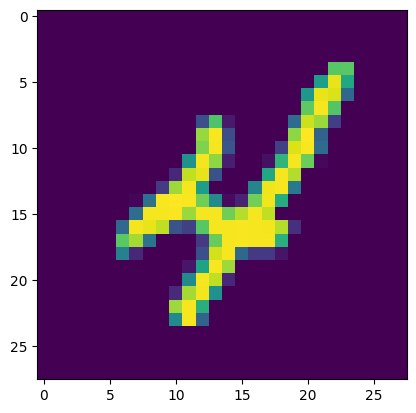

In [5]:
import matplotlib.pyplot as plt

plt.imshow(X_train[9])

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [7]:
class BobNet(nn.Module):
    def __init__(self):
        super(BobNet, self).__init__()
        self.l1 = nn.Linear(784, 128)
        self.l2 = nn.Linear(128, 10)
    def forward(self, x):
        x = F.relu(self.l1(x))
        x = self.l2(x)

        return x

model = BobNet()

BS = 32

lossfn = nn.CrossEntropyLoss()

optim = torch.optim.Adam(model.parameters())

losses, accs = [], []

for i in range(1000):
    optim.zero_grad()

    samp = np.random.randint(0, X_train.shape[0], size=(BS))
    X = torch.tensor(X_train[samp].reshape((-1, 28*28))).float()
    Y = torch.tensor(Y_train[samp]).long()

    out = model(X)
    cat = torch.argmax(out, dim=1)
    accuracy = (cat == Y).float().mean()
    loss = lossfn(out, Y)

    loss.backward()

    optim.step()
    loss, accuracy = loss.item(), accuracy.item()
    losses.append(loss)
    accs.append(accuracy)

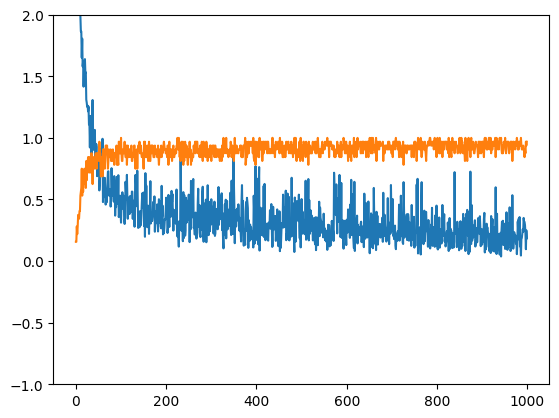

In [8]:
plt.ylim(-1, 2)
plt.plot(losses)
plt.plot(accs)

In [9]:
preds = torch.argmax(model(torch.tensor(X_test).reshape((-1, 28*28)).float()), dim=1).numpy()
print("Accuracy of model is: %.2f" % (Y_test == preds).mean())

Accuracy of model is: 0.94


In [ ]:
l1 = np.zeros((784, 128), dtype=np.float32)
l2 = np.zeros((128, 10), dtype=np.float32)

l1[:] = model.l1.weight.detach().numpy().T
l2[:] = model.l2.weight.detach().numpy().T

def forward(x):
    x = x @ l1
    x = np.maximum(x, 0)
    x = x @ l2
    return x

out = forward(X_test.reshape((-1, 28*28)))
Y_preds = np.argmax(out, axis=1)
# same thing - Hurray!
print("Accuracy of model is: %.2f" % (Y_test == preds).mean())

Accuracy of model is: 0.94


In [ ]:
# trying to figure out how to implement loss function
print(out[0, 7])

print(np.log(np.exp(out[0]).sum()))

-out[0, 7] + np.log(np.exp(out[0]).sum())

8.03841911520434
8.045733165417401


np.float64(0.007314050213061307)

[0.00731405 0.03238536 0.02519338 ... 0.0162948  0.00175892 0.00011994]


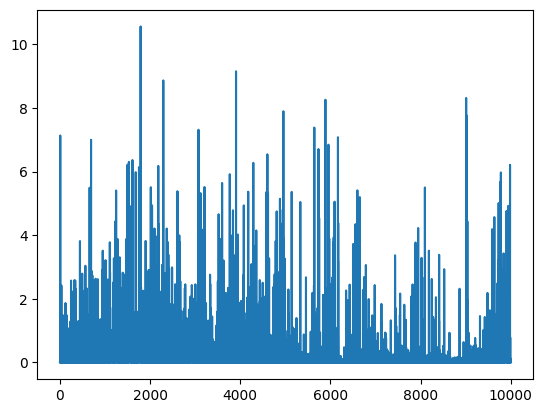

In [36]:
r = -out[range(out.shape[0]), Y_test] + np.log(np.exp(out[range(out.shape[0])]).sum(axis=1))
print(r)
plt.plot(r)

1790


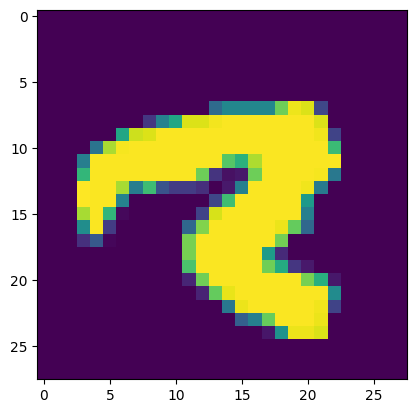

In [48]:
idx = np.argmax(r)

print(idx)

plt.imshow(X_test[idx])

# the worst result is for ...
# two I guess

In [ ]:
# What else is confusing?
sorted(list(zip(r, range(r.shape[0]))), reverse=True)

[(np.float64(10.564954138845883), 1790),
 (np.float64(9.155199678022315), 3906),
 (np.float64(8.868696404080284), 2293),
 (np.float64(8.317233720698802), 9009),
 (np.float64(8.262047250285232), 5888),
 (np.float64(7.900484350082841), 4956),
 (np.float64(7.7616185278279595), 9024),
 (np.float64(7.385509830627485), 5642),
 (np.float64(7.31762184809312), 3073),
 (np.float64(7.135830954838824), 8),
 (np.float64(7.082062164798564), 6166),
 (np.float64(7.0023347029915115), 691),
 (np.float64(6.848410702167262), 5955),
 (np.float64(6.7106777474778845), 5734),
 (np.float64(6.545205246206136), 4601),
 (np.float64(6.3652550912244), 1609),
 (np.float64(6.307234842569908), 1530),
 (np.float64(6.276369706521221), 4289),
 (np.float64(6.220141915297177), 1500),
 (np.float64(6.214433607392796), 9982),
 (np.float64(6.180851660175991), 2182),
 (np.float64(6.143514622072602), 1754),
 (np.float64(5.98514286965139), 1681),
 (np.float64(5.975761523400935), 9779),
 (np.float64(5.92061326809068), 3767),
 (np.

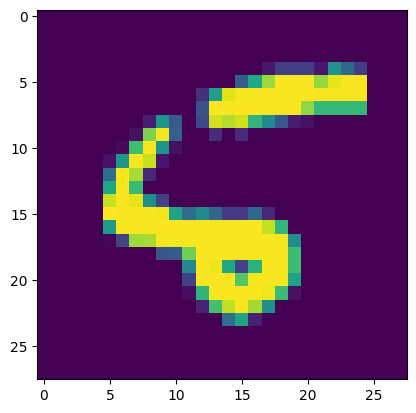

In [ ]:
plt.imshow(X_test[8]) # the hell is that?